In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [13]:
plt.rcParams['figure.figsize'] = [15, 5]

In [11]:
path = '../../../images/Vien_overexposure.jpg'
img = cv2.imread(path, flags=cv2.IMREAD_COLOR_RGB)

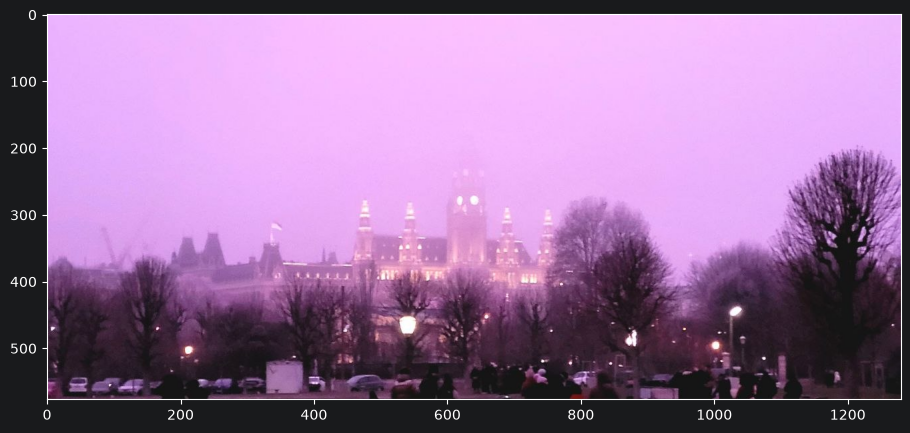

In [14]:
plt.imshow(img)
plt.show()

In [15]:
red, green, blue = cv2.split(img)

([<matplotlib.lines.Line2D at 0x2269dd0fc50>], None)

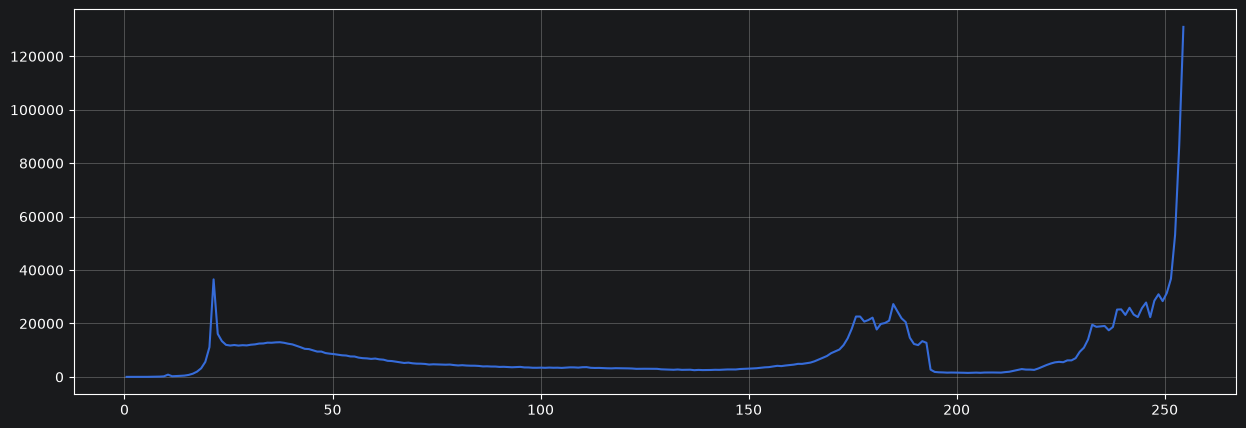

In [17]:
hist, bins = np.histogram(img.ravel(), bins=256, range=(0,255))
plt.plot(bins[0:-1]+0.5, hist), plt.grid(True)

In [31]:
# Equalize luma only
image_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
hue, saturation, value = cv2.split(image_hsv)

equalized_value = cv2.equalizeHist(value)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_value = clahe.apply(value)

equalized_out = cv2.cvtColor(cv2.merge([hue, saturation, equalized_value]), cv2.COLOR_HSV2RGB)
clahe_out = cv2.cvtColor(cv2.merge([hue, saturation, clahe_value]), cv2.COLOR_HSV2RGB)

(<Axes: title={'center': 'CLAHE'}>,
 (np.float64(-0.5), np.float64(1279.5), np.float64(576.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'CLAHE'))

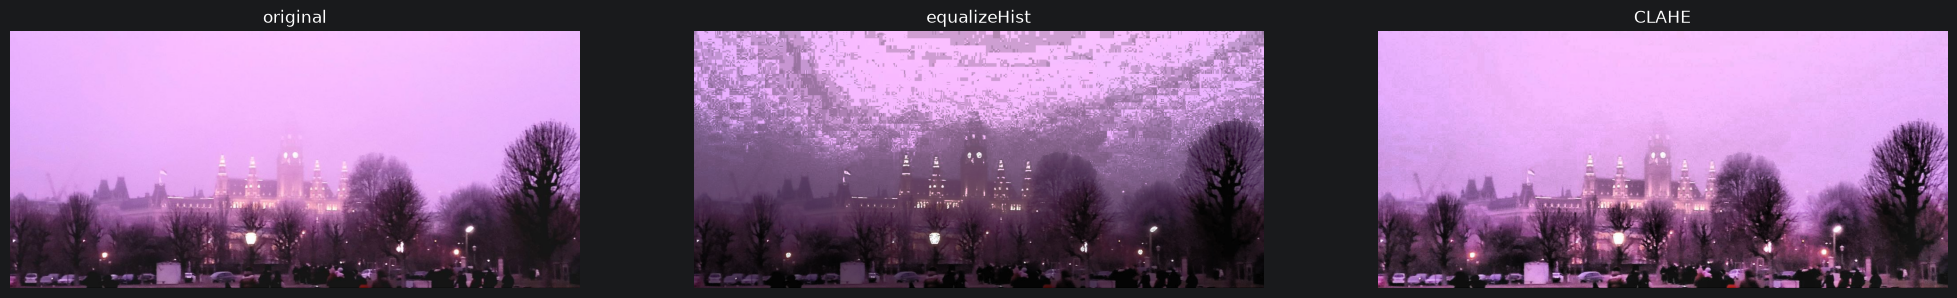

In [33]:
plt.rcParams['figure.figsize'] = [25, 15]

plt.subplot(1,3,1), plt.imshow(img), plt.axis(False), plt.title('original')
plt.subplot(1,3,2), plt.imshow(equalized_out), plt.axis(False), plt.title('equalizeHist')
plt.subplot(1,3,3), plt.imshow(clahe_out), plt.axis(False), plt.title('CLAHE')